# Etapa 2 — Análise Exploratória de Dados

Entrada: os CSVs que a Etapa 1 gravou em `../data/raw/`.
Saída: uma tabela horária limpa em `../data/processed/dataset.csv`, mais os
gráficos e as conclusões que sustentam o que você vai afirmar.

As seções abaixo são um roteiro, não uma receita. Responda as perguntas de
cada uma com código e, no fim, em texto. Acrescente seções se quiser.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

DIR_RAW = Path("..") / "data" / "raw"
DIR_PROC = Path("..") / "data" / "processed"
DIR_PROC.mkdir(parents=True, exist_ok=True)

## 1. Carregar os CSVs

Leia os quatro arquivos de `../data/raw/`.

- Quantas linhas tem cada um? O número faz sentido para o período coletado?
- Os tipos vieram certos, ou datas e números chegaram como texto?
- Há colunas vazias, ou linhas duplicadas?

In [2]:
mares = pd.read_csv(DIR_RAW / "mares_2025.csv")
mares_previsao = pd.read_csv(DIR_RAW / "mares_previsao.csv")
ondas = pd.read_csv(DIR_RAW / "ondas.csv")
vento = pd.read_csv(DIR_RAW / "vento.csv")

for nome, tabela in [("mares_2025", mares), ("mares_previsao", mares_previsao), ("ondas", ondas), ("vento", vento)]:
    print(nome, tabela.shape, "nulos:", tabela.isna().sum().sum(), "duplicadas:", tabela.duplicated().sum())
ondas.dtypes

mares_2025 (1410, 5) nulos: 0 duplicadas: 0
mares_previsao (120, 5) nulos: 0 duplicadas: 0
ondas (168, 4) nulos: 0 duplicadas: 0
vento (168, 4) nulos: 0 duplicadas: 0


data                 str
hora                 str
altura_onda_m    float64
direcao              str
dtype: object

Os quatro arquivos vieram sem nulos nem duplicatas. A tábua de 2025 tem 1410 marés (cerca de 4 por dia), a de outubro tem 120, e ondas e vento têm 168 linhas cada (7 dias × 24 horas). Só `data` e `hora` vieram como texto.

## 2. Limpeza

Deixe cada tabela num estado em que dá para confiar.

- Datas e horas: viram `datetime`? Vale montar uma coluna única de data + hora?
- Decimais: o site usa vírgula. Isso já foi resolvido na Etapa 1 ou sobrou aqui?
- O que fazer com nulos: descartar a linha, preencher, ou manter e documentar?
- Duplicatas: existem? De onde vieram?

In [3]:
def juntar_data_hora(tabela):
    tabela = tabela.copy()
    tabela["datetime"] = pd.to_datetime(tabela["data"] + " " + tabela["hora"])
    return tabela.drop(columns=["data", "hora"])

mares = juntar_data_hora(mares)
mares_previsao = juntar_data_hora(mares_previsao)
ondas = juntar_data_hora(ondas)
vento = juntar_data_hora(vento)
ondas.head()

,altura_onda_m,direcao,datetime
0,1.1,E,2026-10-08 00:00:00
1,1.1,E,2026-10-08 01:00:00
2,1.1,E,2026-10-08 02:00:00
3,1.1,E,2026-10-08 03:00:00
4,1.1,E,2026-10-08 04:00:00


Juntei data e hora numa coluna só (`datetime`). Os decimais já vieram certos da Etapa 1.

## 3. Explorar cada tabela separadamente

Antes de juntar, entenda cada fonte.

**Marés** — como a altura se distribui entre marés altas e baixas? O
coeficiente varia ao longo do ano com algum padrão? Ele tem relação com a
fase da lua?

**Ondas** — qual a faixa de altura na janela coletada? Há padrão por hora do
dia, ou a variação é só por dia?

**Vento** — quais horas são mais calmas? A direção predominante muda ao longo
do dia? (Vento da terra para o mar e vento do mar para a terra fazem coisas
opostas com a onda.)

Um gráfico por pergunta. Escreva o que você leu nele.

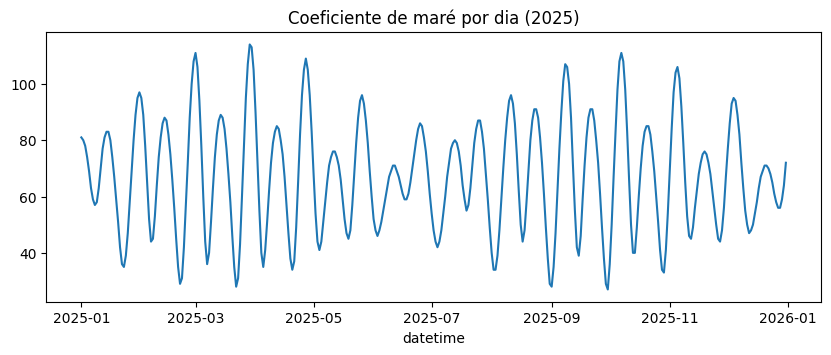

In [4]:
dias = mares.groupby(mares["datetime"].dt.date)["coeficiente"].first()
dias.plot(figsize=(10, 3.5), title="Coeficiente de maré por dia (2025)")
plt.show()

O coeficiente sobe e desce a cada duas semanas, entre 27 e 114.

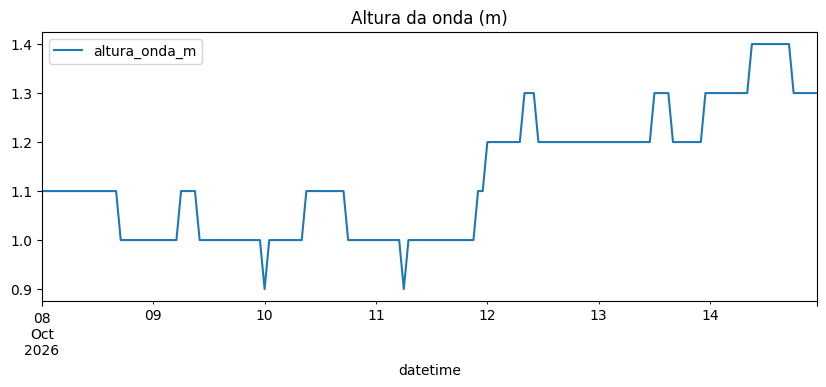

In [5]:
ondas.plot(x="datetime", y="altura_onda_m", figsize=(10, 3.5), title="Altura da onda (m)")
plt.show()

A onda fica entre 0,9 e 1,4 m. Ela é menor de 08 a 11/10 e maior de 12 a 14/10.

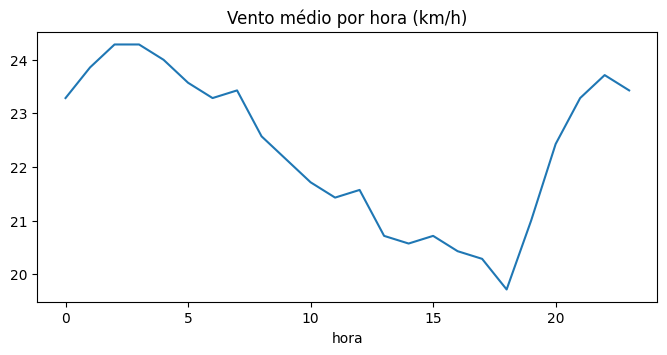

direcao
ESE    70
E      49
SE     45
SSE     4
Name: count, dtype: int64

In [6]:
vento["hora"] = vento["datetime"].dt.hour
vento.groupby("hora")["vento_kmh"].mean().plot(figsize=(8, 3.5), title="Vento médio por hora (km/h)")
plt.show()
vento["direcao"].value_counts()

O vento é mais fraco no fim da tarde (cerca de 20 km/h) e mais forte de madrugada (cerca de 24 km/h). Ele vem sempre de leste ou sudeste, ou seja, do mar para a terra.

## 4. Juntar as tabelas

Esta é a parte difícil, e ela tem mais de uma resposta certa.

As granularidades não batem: onda e vento são leituras horárias; maré são ~4
eventos por dia (os instantes de máxima e mínima). Para ter uma linha por hora
com as três informações você precisa decidir:

- Como levar a maré para a grade horária? Interpolar entre eventos? Repetir o
  último valor? Guardar apenas se a maré está subindo ou descendo? O que cada
  escolha assume sobre a curva real da maré — e onde essa suposição erra?
- Qual o tipo de junção? A previsão de onda e a de vento cobrem exatamente as
  mesmas horas? Se não, você mantém as horas incompletas ou corta?
- Que variáveis derivadas de tempo ajudam a responder a pergunta do projeto
  (dia da semana, período do dia, ...)?

Justifique as escolhas em markdown. Elas são a base das duas próximas etapas.

- **Ondas e vento** têm uma leitura por hora, então uso `merge` com as duas.
- **Maré:** uso o valor da última maré registrada antes de cada hora (`merge_asof`). Se a última foi baixa, a maré está subindo; se foi alta, está descendo. Isso erra no meio do caminho entre as marés, porque a altura real muda ao longo das horas.

In [7]:
dados = ondas.rename(columns={"direcao": "direcao_onda"}).merge(
    vento.drop(columns="hora").rename(columns={"direcao": "direcao_vento"}), on="datetime"
)
print(len(ondas), len(vento), len(dados))

168 168 168


In [8]:
ultima_mare = mares_previsao.sort_values("datetime").rename(columns={"altura_m": "mare_m"})
dados = pd.merge_asof(dados.sort_values("datetime"), ultima_mare[["datetime", "mare_m", "tipo"]], on="datetime")
dados["mare_subindo"] = (dados["tipo"] == "baixa").astype(int)
dados = dados.drop(columns="tipo")

dados["hora"] = dados["datetime"].dt.hour
dados["dia_semana"] = dados["datetime"].dt.dayofweek
dados.head()

,altura_onda_m,direcao_onda,datetime,vento_kmh,direcao_vento,mare_m,mare_subindo,hora,dia_semana
0,1.1,E,2026-10-08 00:00:00,21.0,SE,0.4,1,0,3
1,1.1,E,2026-10-08 01:00:00,22.0,SE,0.4,1,1,3
2,1.1,E,2026-10-08 02:00:00,20.0,SE,0.4,1,2,3
3,1.1,E,2026-10-08 03:00:00,18.0,SSE,2.4,0,3,3
4,1.1,E,2026-10-08 04:00:00,18.0,SSE,2.4,0,4,3


A junção manteve as 168 horas, sem nulos.

## 5. Visualizações voltadas à pergunta

Agora com a tabela junta: quando as condições coincidem?

- As horas de onda maior são as mesmas de vento mais fraco, ou elas se
  desencontram?
- Existe relação visível entre altura da maré e altura da onda?
- Quais dias e horas da janela se destacam?

Prefira poucos gráficos legíveis a muitos gráficos.

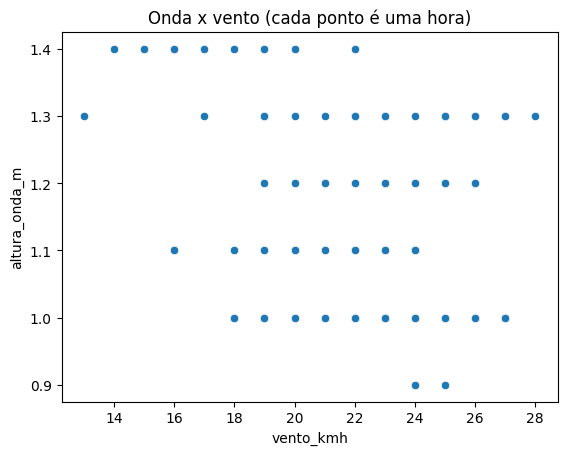

np.float64(-0.29469868012498074)

In [9]:
sns.scatterplot(data=dados, x="vento_kmh", y="altura_onda_m")
plt.title("Onda x vento (cada ponto é uma hora)")
plt.show()
dados["altura_onda_m"].corr(dados["vento_kmh"])

A correlação é -0,29: onda maior tende a vir com vento um pouco mais fraco, mas a relação é fraca.

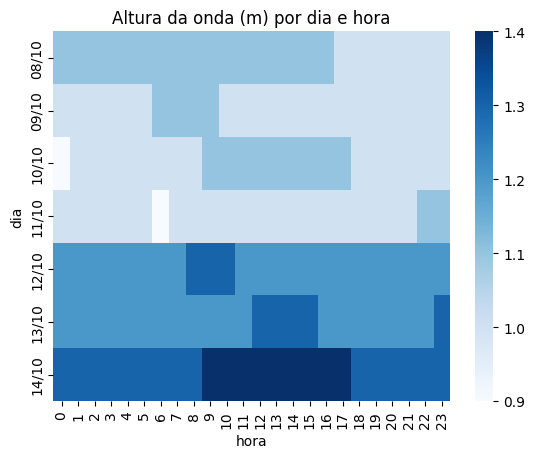

In [10]:
dados["dia"] = dados["datetime"].dt.strftime("%d/%m")
sns.heatmap(dados.pivot(index="dia", columns="hora", values="altura_onda_m"), cmap="Blues")
plt.title("Altura da onda (m) por dia e hora")
plt.show()

O dia 14/10 se destaca, com ondas de 1,4 m entre 9h e 17h. Os dias 09 a 11/10 têm as ondas mais baixas.

## 6. Salvar o dataset processado

Grave o resultado em `../data/processed/dataset.csv`. A Etapa 3 lê esse
arquivo — se as colunas mudarem depois, o notebook de ML muda também.

In [11]:
dados = dados.drop(columns="dia")
dados.to_csv(DIR_PROC / "dataset.csv", index=False)
print(dados.shape)

(168, 9)


## 7. Conclusões

Em texto, sem código:

1. O que os dados mostram sobre as condições da janela coletada?
2. Que decisão de limpeza ou de junção você tomou que mais influencia o
   resultado, e por quê?
3. O que esses dados **não** permitem afirmar?

1. A onda sobe de cerca de 1,0 m para 1,4 m ao longo da semana. O melhor momento é a tarde de 14/10, com onda maior e vento mais fraco.
2. A decisão que mais pesa é como tratar a maré: usei só o valor da última maré registrada, que é simples mas aproximado.
3. Os dados cobrem só uma semana, então não dizem qual a melhor época do ano. Também não têm o período da onda, e a previsão tem erro.